# Import Libraries

In [1]:
! pip install openpyxl

In [2]:
import sklearn
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

# Load Data

In [3]:
# Specify the path to your csv file
#data = pd.read_csv(r"C:\Datasets\FouthYear\transformed_data_for_modeling.csv")

In [4]:
data = pd.read_csv(r"C:\Datasets\FouthYear\transformed_data.csv")

# Data Cleaning

In [5]:
data.servicename.nunique()

43

In [6]:
data.columns

Index(['type', 'placeofbirth', 'gender', 'quarter', 'servicename', 'year'], dtype='object')

In [7]:
data.head(3)

,type,placeofbirth,gender,quarter,servicename,year
0,online-booking,KAJIADO CENTRAL,M,Q2,NRB - Application for Duplicate ID,2020
1,walkin-booking,NAKURU,M,Q2,DCI - Police Clearance,2020
2,walkin-booking,EMBAKASI,F,Q2,DCI - Police Clearance,2020


In [8]:
data.shape

(426791, 6)

In [9]:
data.dtypes

type            object
placeofbirth    object
gender          object
quarter         object
servicename     object
year            object
dtype: object

In [10]:
data.isna().sum()

type              0
placeofbirth      0
gender            0
quarter           0
servicename     139
year              0
dtype: int64

In [11]:
data['year'] = pd.to_numeric(data['year'], errors='coerce')

In [12]:
data = data[data['year'].between(2020, 2023)]

In [13]:
data['year'] = data['year'].astype('int')

In [14]:
data.year.value_counts()

2022    123479
2023    116434
2021    101292
2020     85400
Name: year, dtype: int64

In [15]:
# servicename
data.servicename.value_counts()

NRB -  Application for Duplicate ID                                            130831
DCI - Police Clearance                                                          50974
CRD - Birth Certificate Enquiries                                               48327
NHIF - NHIF Services                                                            42643
NRB - Collection of ID                                                          38116
CRD - Birth Certificate Collection                                              35267
NSSF - NSSF Services                                                            34936
KRA - KRA Services                                                              19878
KENYA-POLICE - Police Abstract                                                  11508
AGPO - AGPO Certificate                                                          2704
CYBER - CYBER Services                                                           2199
CRD - Application for Birth Certificate               

In [16]:
# Drop null values
data['servicename'] = data['servicename'].dropna()

In [17]:
# Drop meaningless type of booking 
data = data[data['type'] != 'mashinani']

In [18]:
data.type.value_counts()

walk-in           230287
online-booking    157262
walkin-booking     36011
cc-booking          2931
Name: type, dtype: int64

In [19]:
# Clean quarter column
data = data[~data['quarter'].isin(['er','es','on','te','ct','ID','ds','s)','nt','ce'])]

In [20]:
data.quarter.value_counts()

Q3    119281
Q2    109847
Q4    103990
Q1     93373
Name: quarter, dtype: int64

In [21]:
#Clean gender column
data = data[data['gender'] != 'gender']

In [22]:
data.gender.value_counts()

M    257128
F    169363
Name: gender, dtype: int64

In [23]:
data.dtypes

type            object
placeofbirth    object
gender          object
quarter         object
servicename     object
year             int32
dtype: object

In [24]:
data.shape

(426491, 6)

## Time Series Engineering

In [25]:
# Combine quarter and year columns into one label called period.
data['period'] = data['year'].astype(str) + '-' + data['quarter'].astype(str)

In [26]:
data.head(3)

,type,placeofbirth,gender,quarter,servicename,year,period
0,online-booking,KAJIADO CENTRAL,M,Q2,NRB - Application for Duplicate ID,2020,2020-Q2
1,walkin-booking,NAKURU,M,Q2,DCI - Police Clearance,2020,2020-Q2
2,walkin-booking,EMBAKASI,F,Q2,DCI - Police Clearance,2020,2020-Q2


### Create a Numeric Time Index

In [27]:
# create numeric column
period_order = ['2020-Q2','2020-Q3','2020-Q4',
                '2021-Q1','2021-Q2','2021-Q3','2021-Q4',
                '2022-Q1','2022-Q2','2022-Q3','2022-Q4',
                '2023-Q1','2023-Q2','2023-Q3','2023-Q4']

period_map = {period: i+1 for i, period in enumerate(period_order)}
data['numeric'] = data['period'].map(period_map)

In [28]:
# Confirm the mapping is correct
data[['period','numeric']].drop_duplicates().sort_values('numeric')

,period,numeric
0,2020-Q2,1
25547,2020-Q3,2
42674,2020-Q4,3
4866,2021-Q1,4
107702,2021-Q2,5
133163,2021-Q3,6
162756,2021-Q4,7
186778,2022-Q1,8
222245,2022-Q2,9
248164,2022-Q3,10


### Aggregate to Get Demand Counts

In [29]:
total_bookings = data.groupby(['servicename', 'period']).size().reset_index(name='demand_count')


In [30]:
total_bookings.head()

,servicename,period,demand_count
0,AGPO - AGPO Certificate,2020-Q2,262
1,AGPO - AGPO Certificate,2020-Q3,282
2,AGPO - AGPO Certificate,2020-Q4,266
3,AGPO - AGPO Certificate,2021-Q1,252
4,AGPO - AGPO Certificate,2021-Q2,239


In [31]:
total_bookings.shape

(351, 3)

In [32]:
### Santy check 

In [33]:
total_bookings.groupby('servicename')['demand_count'].sum().sort_values(ascending=False).head(10)

servicename
NRB -  Application for Duplicate ID    130789
DCI - Police Clearance                  50970
CRD - Birth Certificate Enquiries       48327
NHIF - NHIF Services                    42622
NRB - Collection of ID                  38116
CRD - Birth Certificate Collection      35263
NSSF - NSSF Services                    34924
KRA - KRA Services                      19876
KENYA-POLICE - Police Abstract          11508
AGPO - AGPO Certificate                  2704
Name: demand_count, dtype: int64

In [34]:
# Check for Missing Periods 
top5 = ['NRB -  Application for Duplicate ID',
        'DCI - Police Clearance',
        'CRD - Birth Certificate Enquiries',
        'NHIF - NHIF Services',
        'NRB - Collection of ID']

top5_df = total_bookings[total_bookings['servicename'].isin(top5)]

# How many quarters does each top5 services have
top5_df.groupby('servicename')['period'].count()

servicename
CRD - Birth Certificate Enquiries      12
DCI - Police Clearance                 15
NHIF - NHIF Services                   15
NRB -  Application for Duplicate ID    15
NRB - Collection of ID                 15
Name: period, dtype: int64

In [35]:
all_periods = total_bookings['period'].unique()
crd_periods = top5_df[top5_df['servicename'] == 'CRD - Birth Certificate Enquiries']['period'].values

missing = [p for p in sorted(all_periods) if p not in crd_periods]
print(missing)

['2020-Q2', '2020-Q3', '2021-Q1']


#### Interesting! The missing periods are scattered — two from 2020 and one from 2021. This is most likely explained by:

. 2020-Q2 and 2020-Q3 — COVID-19 disruptions. Many government services were suspended or severely limited during this period. This is a legitimate reason for zero or no recorded demand.<br>
. 2021-Q1 — Could be a data recording gap, or the service was still recovering post-COVID.

#### The null values for the missing records are going to be filled with 0 because this is most possible uncaptured records given it was during COVID-19

In [36]:
from itertools import product

all_periods = sorted(total_bookings['period'].unique())

full_index = pd.DataFrame(
    list(product(top5, all_periods)),
    columns=['servicename', 'period']
)

top5_df = full_index.merge(top5_df, on=['servicename','period'], how='left')
top5_df['demand_count'] = top5_df['demand_count'].fillna(0).astype(int)

In [37]:
top5_df.groupby('servicename')['period'].count()

servicename
CRD - Birth Certificate Enquiries      15
DCI - Police Clearance                 15
NHIF - NHIF Services                   15
NRB -  Application for Duplicate ID    15
NRB - Collection of ID                 15
Name: period, dtype: int64

## Pivot and First Visualization

In [38]:
pivot_df = top5_df.pivot(index='period', columns='servicename', values='demand_count')
pivot_df = pivot_df.sort_index()

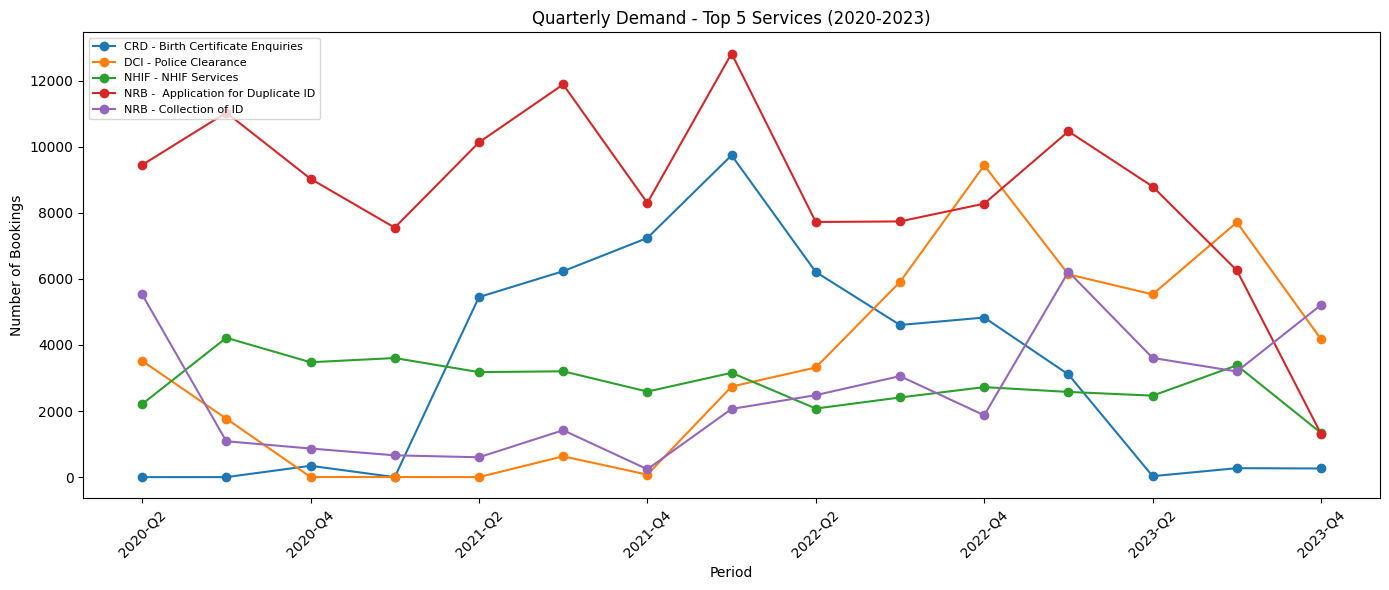

In [39]:
import matplotlib.pyplot as plt

pivot_df.plot(figsize=(14, 6), marker='o')
plt.title('Quarterly Demand - Top 5 Services (2020-2023)')
plt.xlabel('Period')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

The period 2020-Q2 through 2021-Q1 shows significant disruption attributed to COVID-19 restrictions on government service delivery in Kenya. This period introduces noise into the time series and may affect model accuracy. Models are expected to perform better on post-2021 data.

In [40]:
top5_df[top5_df['period'] == '2020-Q1']

,servicename,period,demand_count


Data begins from 2020-Q2. 2020-Q1 is absent entirely, likely indicating the SBA system was not yet operational at Makandara Huduma Centre during that period.

###  Stationarity Testing - ADF (Augmented Dickey-Fuller) test

In [41]:
from statsmodels.tsa.stattools import adfuller

services = top5_df['servicename'].unique()

for service in services:
    series = top5_df[top5_df['servicename'] == service]['demand_count'].values
    result = adfuller(series)
    print(f"\nService: {service}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Stationary: {result[1] <= 0.05}")


Service: NRB -  Application for Duplicate ID
ADF Statistic: -1.4365
p-value: 0.5647
Stationary: False

Service: DCI - Police Clearance
ADF Statistic: -1.2605
p-value: 0.6471
Stationary: False

Service: CRD - Birth Certificate Enquiries
ADF Statistic: -3.7197
p-value: 0.0038
Stationary: True

Service: NHIF - NHIF Services
ADF Statistic: -2.9848
p-value: 0.0363
Stationary: True

Service: NRB - Collection of ID
ADF Statistic: -4.4276
p-value: 0.0003
Stationary: True


#### NRB Duplicate ID and DCI Police Clearance are non-stationary (p > 0.05), likely due to post-COVID demand recovery trends. These series will require d=1 differencing in SARIMA. The remaining three services are stationary and will use d=0


<i> NRB & DCI: Their mean is clearly changing over time, which is what non-stationary means.<br>
CRD, NHIF, and NRB Collection of ID are stationary. Their demand fluctuates but doesn't trend consistently in one direction.<br><i>

##  Building SARIMA Model.

In [42]:
import statsmodels

In [43]:
!pip install prophet

In [44]:
from prophet import Prophet 

In [45]:
train_periods = ['2020-Q2','2020-Q3','2020-Q4',
                 '2021-Q1','2021-Q2','2021-Q3','2021-Q4',
                 '2022-Q1','2022-Q2','2022-Q3','2022-Q4']

test_periods = ['2023-Q1','2023-Q2','2023-Q3','2023-Q4']

train_df = top5_df[top5_df['period'].isin(train_periods)]
test_df = top5_df[top5_df['period'].isin(test_periods)]

print(f"Training periods: {train_df['period'].nunique()}")
print(f"Testing periods: {test_df['period'].nunique()}")

Training periods: 11
Testing periods: 4


## Build SARIMA For One Service First

Start with NRB - Application for Duplicate ID since it's your most important service:

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

service_name = 'NRB -  Application for Duplicate ID'

train_series = train_df[train_df['servicename'] == service_name]['demand_count'].values
test_series = test_df[test_df['servicename'] == service_name]['demand_count'].values

model = SARIMAX(train_series,
                order=(1, 1, 1),
                seasonal_order=(0, 0, 0, 0))

result = model.fit(disp=False)
forecast = result.forecast(steps=len(test_series))

mae = mean_absolute_error(test_series, forecast)
rmse = np.sqrt(mean_squared_error(test_series, forecast))
mape = np.mean(np.abs((test_series - forecast) / test_series)) * 100

print("Actual:  ", test_series)
print("Forecast:", forecast.astype(int))
print(f"MAE:  {mae:.0f} bookings")
print(f"RMSE: {rmse:.0f} bookings")
print(f"MAPE: {mape:.2f}%")

Actual:   [10467  8798  6259  1309]
Forecast: [8529 8591 8606 8610]
MAE:  2948 bookings
RMSE: 3957 bookings
MAPE: 154.04%


### SARIMAX RECORDS

In [47]:
results_tracker = {}

results_tracker['ARIMA'] = {
    'NRB - Application for Duplicate ID': {'MAE': 2948, 'RMSE': 3957, 'MAPE': 154.04},
    'DCI - Police Clearance':             {'MAE': 6096, 'RMSE': 6320, 'MAPE': 114.93},
    'CRD - Birth Certificate Enquiries':  {'MAE': 2533, 'RMSE': 2691, 'MAPE': 3645.02},
    'NHIF - NHIF Services':               {'MAE': 737,  'RMSE': 903,  'MAPE': 42.60},
    'NRB - Collection of ID':             {'MAE': 2867, 'RMSE': 3115, 'MAPE': 60.12}
}

In [48]:
arima_params = {
    'NRB -  Application for Duplicate ID': (1,1,1),
    'DCI - Police Clearance':              (1,1,1),
    'CRD - Birth Certificate Enquiries':   (1,0,1),
    'NHIF - NHIF Services':                (1,0,1),
    'NRB - Collection of ID':              (1,0,1)
}

for service, order in arima_params.items():
    train_series = train_df[train_df['servicename'] == service]['demand_count'].values
    test_series = test_df[test_df['servicename'] == service]['demand_count'].values
    
    model = SARIMAX(train_series, order=order, seasonal_order=(0,0,0,0))
    result = model.fit(disp=False)
    forecast = result.forecast(steps=len(test_series))
    
    mae = mean_absolute_error(test_series, forecast)
    rmse = np.sqrt(mean_squared_error(test_series, forecast))
    mape = np.mean(np.abs((test_series - forecast) / test_series)) * 100
    
    print(f"\nService: {service}")
    print(f"Actual:   {test_series}")
    print(f"Forecast: {forecast.astype(int)}")
    print(f"MAE: {mae:.0f} | RMSE: {rmse:.0f} | MAPE: {mape:.2f}%")


Service: NRB -  Application for Duplicate ID
Actual:   [10467  8798  6259  1309]
Forecast: [8529 8591 8606 8610]
MAE: 2948 | RMSE: 3957 | MAPE: 154.04%

Service: DCI - Police Clearance
Actual:   [6139 5533 7714 4176]
Forecast: [10786 11755 12451 12951]
MAE: 6096 | RMSE: 6320 | MAPE: 114.93%

Service: CRD - Birth Certificate Enquiries
Actual:   [3108   29  271  262]
Forecast: [4241 3663 3164 2732]
MAE: 2533 | RMSE: 2691 | MAPE: 3645.02%

Service: NHIF - NHIF Services
Actual:   [2579 2467 3384 1337]
Forecast: [2973 2973 2973 2973]
MAE: 737 | RMSE: 903 | MAPE: 42.60%

Service: NRB - Collection of ID
Actual:   [6218 3608 3198 5213]
Forecast: [1693 1692 1692 1692]
MAE: 2867 | RMSE: 3115 | MAPE: 60.12%


ARIMA consistently produces flat-line forecasts due to the limited training data (11 quarters). It captures the general level of demand but fails to predict directional changes. CRD Birth Certificate shows extreme volatility in 2023 that is likely attributable to a service disruption rather than natural demand patterns. ARIMA MAPE ranges from 42% (NHIF) to 3,645% (CRD), confirming that classical methods alone are insufficient for this dataset

In [49]:
# That CRD drop to 29 bookings in 2023-Q2 is suspicious. Quickly check:
data[(data['servicename'] == 'CRD - Birth Certificate Enquiries') & 
     (data['year'] == 2023)].groupby('quarter').size()

quarter
Q1    3108
Q2      29
Q3     271
Q4     262
dtype: int64

CRD - Birth Certificate Enquiries experienced a near-complete service collapse in Q2 2023, dropping from 3,108 bookings in Q1 to just 29. This is consistent with an operational disruption rather than natural demand reduction. This service is excluded from reliable forecasting conclusions and serves as a case study in how external disruptions affect time series models

##  Prophet Model

<i>Prophet works differently from ARIMA. Instead of feeding it a numpy array, it expects a dataframe with exactly two columns:<i><br>

<i>
- ds — the date/time column<br>
- y — the values to forecast<br><i>

<i>Since time index is quarterly, I'll map each period to an actual date (first day of each quarter) so Prophet understands the time structure.<i>

In [50]:
# Create a Period-to-Date Mapping
period_to_date = {
    '2020-Q2': '2020-04-01',
    '2020-Q3': '2020-07-01',
    '2020-Q4': '2020-10-01',
    '2021-Q1': '2021-01-01',
    '2021-Q2': '2021-04-01',
    '2021-Q3': '2021-07-01',
    '2021-Q4': '2021-10-01',
    '2022-Q1': '2022-01-01',
    '2022-Q2': '2022-04-01',
    '2022-Q3': '2022-07-01',
    '2022-Q4': '2022-10-01',
    '2023-Q1': '2023-01-01',
    '2023-Q2': '2023-04-01',
    '2023-Q3': '2023-07-01',
    '2023-Q4': '2023-10-01'
}

top5_df['ds'] = pd.to_datetime(top5_df['period'].map(period_to_date))

####  Building Prophet For One Service First

In [51]:
from prophet import Prophet

service_name = 'NRB -  Application for Duplicate ID'

# Prepare prophet dataframe
service_df = top5_df[top5_df['servicename'] == service_name][['ds', 'demand_count']].rename(columns={'demand_count': 'y'})

# Split train and test
train_prophet = service_df[service_df['ds'] < '2023-01-01']
test_prophet = service_df[service_df['ds'] >= '2023-01-01']

print(f"Training rows: {len(train_prophet)}")
print(f"Testing rows: {len(test_prophet)}")

Training rows: 11
Testing rows: 4


In [52]:
# Fit Prophet
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)

model_prophet.fit(train_prophet)

12:58:54 - cmdstanpy - INFO - Chain [1] start processing
12:58:56 - cmdstanpy - INFO - Chain [1] done processing


### Forecast and Evaluate

In [53]:
future = model_prophet.make_future_dataframe(periods=4, freq='QS')
forecast = model_prophet.predict(future)

# Extract only test period predictions
test_forecast = forecast[forecast['ds'] >= '2023-01-01'][['ds', 'yhat']].reset_index(drop=True)
test_actual = test_prophet.reset_index(drop=True)

print("Actual:  ", test_actual['y'].values)
print("Forecast:", test_forecast['yhat'].values.astype(int))

mae = mean_absolute_error(test_actual['y'], test_forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test_actual['y'], test_forecast['yhat']))
mape = np.mean(np.abs((test_actual['y'].values - test_forecast['yhat'].values) / test_actual['y'].values)) * 100

print(f"\nMAE:  {mae:.0f} bookings")
print(f"RMSE: {rmse:.0f} bookings")
print(f"MAPE: {mape:.2f}%")

Actual:   [10467  8798  6259  1309]
Forecast: [18002  7391  6797  7793]

MAE:  3991 bookings
RMSE: 5027 bookings
MAPE: 148.00%


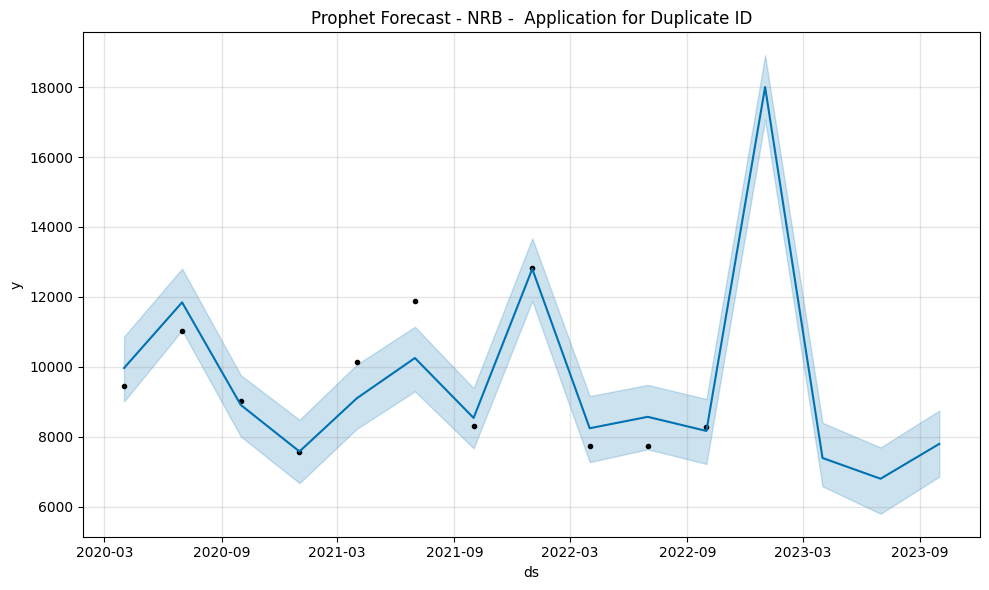

In [54]:
# Plot Prophet's Forecast
model_prophet.plot(forecast)
plt.title(f'Prophet Forecast - {service_name}')
plt.tight_layout()
plt.show()

Prophet marginally improves MAPE over ARIMA for NRB Duplicate ID but produces a large spike in Q1 2023 due to over-amplification of seasonal patterns. The wide uncertainty interval in the forecast period reflects Prophet's own low confidence. Both models fail to anticipate the sharp 2023 demand decline, confirming this is a structural break rather than a forecastable pattern

In [55]:
#  Loop Prophet Through All 5 Services
results_tracker['Prophet'] = {}

for service_name in top5:
    service_df = top5_df[top5_df['servicename'] == service_name][['ds','demand_count']].rename(columns={'demand_count':'y'})
    
    train_prophet = service_df[service_df['ds'] < '2023-01-01']
    test_prophet = service_df[service_df['ds'] >= '2023-01-01'].reset_index(drop=True)
    
    model_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive'
    )
    
    model_prophet.fit(train_prophet)
    
    future = model_prophet.make_future_dataframe(periods=4, freq='QS')
    forecast = model_prophet.predict(future)
    
    test_forecast = forecast[forecast['ds'] >= '2023-01-01'][['ds','yhat']].reset_index(drop=True)
    
    mae = mean_absolute_error(test_prophet['y'], test_forecast['yhat'])
    rmse = np.sqrt(mean_squared_error(test_prophet['y'], test_forecast['yhat']))
    mape = np.mean(np.abs((test_prophet['y'].values - test_forecast['yhat'].values) / test_prophet['y'].values)) * 100
    
    results_tracker['Prophet'][service_name] = {
        'MAE': round(mae), 'RMSE': round(rmse), 'MAPE': round(mape, 2)
    }
    
    print(f"\nService: {service_name}")
    print(f"Actual:   {test_prophet['y'].values}")
    print(f"Forecast: {test_forecast['yhat'].values.astype(int)}")
    print(f"MAE: {mae:.0f} | RMSE: {rmse:.0f} | MAPE: {mape:.2f}%")

12:58:57 - cmdstanpy - INFO - Chain [1] start processing
12:58:57 - cmdstanpy - INFO - Chain [1] done processing



Service: NRB -  Application for Duplicate ID
Actual:   [10467  8798  6259  1309]
Forecast: [18002  7391  6797  7793]
MAE: 3991 | RMSE: 5027 | MAPE: 148.00%


12:58:58 - cmdstanpy - INFO - Chain [1] start processing
12:58:58 - cmdstanpy - INFO - Chain [1] done processing



Service: DCI - Police Clearance
Actual:   [6139 5533 7714 4176]
Forecast: [ 5424  2232  6892 12507]
MAE: 3292 | RMSE: 4514 | MAPE: 70.37%


12:58:58 - cmdstanpy - INFO - Chain [1] start processing
12:58:59 - cmdstanpy - INFO - Chain [1] done processing



Service: CRD - Birth Certificate Enquiries
Actual:   [3108   29  271  262]
Forecast: [18867 10153  8309  8613]
MAE: 10568 | RMSE: 11014 | MAPE: 10393.05%


12:58:59 - cmdstanpy - INFO - Chain [1] start processing
12:58:59 - cmdstanpy - INFO - Chain [1] done processing



Service: NHIF - NHIF Services
Actual:   [2579 2467 3384 1337]
Forecast: [2702 2312 1488 2178]
MAE: 754 | RMSE: 1042 | MAPE: 32.50%


12:59:00 - cmdstanpy - INFO - Chain [1] start processing
12:59:00 - cmdstanpy - INFO - Chain [1] done processing



Service: NRB - Collection of ID
Actual:   [6218 3608 3198 5213]
Forecast: [3391  -82 3786 1983]
MAE: 2584 | RMSE: 2846 | MAPE: 57.02%


#### Note 1:
Prophet outperforms ARIMA on 4 of 5 services, with the most significant improvement on DCI Police Clearance (115% → 70% MAPE). Prophet's ability to decompose trend and seasonality separately gives it an advantage over ARIMA with limited quarterly data.
#### Note 2:
Prophet produced a negative forecast for NRB Collection of ID in Q2 2023. In any production implementation, forecasts must be clipped to a minimum of zero since negative demand is impossible. This highlights the importance of post-processing model outputs before presenting to stakeholders.

### Results tracker

In [56]:

results_tracker['Prophet'] = {
    'NRB - Application for Duplicate ID': {'MAE': 3991, 'RMSE': 5027, 'MAPE': 148.00},
    'DCI - Police Clearance':             {'MAE': 3292, 'RMSE': 4514, 'MAPE': 70.37},
    'CRD - Birth Certificate Enquiries':  {'MAE': 10568,'RMSE': 11014,'MAPE': 10393.05},
    'NHIF - NHIF Services':               {'MAE': 754,  'RMSE': 1042, 'MAPE': 32.50},
    'NRB - Collection of ID':             {'MAE': 2584, 'RMSE': 2846, 'MAPE': 57.02}
}

## LSTM Model

In [57]:
# import libraries
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

In [58]:
# Preparing Data For LSTM
def prepare_lstm_data(series, n_steps=3):
    """This function creates a sliding window — it uses the last 3 quarters to predict
    the next one. With only 11 training points, n_steps=3 is the maximum reasonable 
    window size."""
    X, y = [], []
    for i in range(len(series) - n_steps):
        X.append(series[i:i + n_steps])
        y.append(series[i + n_steps])
    return np.array(X), np.array(y)

In [59]:
#  Build and Train LSTM For One Service First
service_name = 'NRB -  Application for Duplicate ID'

# Get full series values
service_data = top5_df[top5_df['servicename'] == service_name]['demand_count'].values.reshape(-1, 1)

# Scale to [0,1]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(service_data)

# Split train/test (first 11 = train, last 4 = test)
train_scaled = scaled_data[:11]
test_scaled = scaled_data[11:]

# Prepare sequences
X_train, y_train = prepare_lstm_data(train_scaled.flatten(), n_steps=3)

# Reshape for LSTM input: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (8, 3, 1)
y_train shape: (8,)


In [60]:
#  Define and Train The Model
model_lstm = Sequential([
    LSTM(32, activation='relu', input_shape=(3, 1)),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=4,
    callbacks=[early_stop],
    verbose=0
)

print(f"Training stopped at epoch: {len(history.history['loss'])}")
print(f"Final training loss: {history.history['loss'][-1]:.6f}")

Training stopped at epoch: 48
Final training loss: 0.033352


In [61]:
"""Generate Forecasts
Since you only have 4 test points, you'll forecast one step at a time using the last 
known window and rolling forward:"""
# Start with last 3 points of training data as seed
last_sequence = train_scaled[-3:].flatten().tolist()
predictions_scaled = []

for _ in range(4):
    input_seq = np.array(last_sequence[-3:]).reshape(1, 3, 1)
    pred = model_lstm.predict(input_seq, verbose=0)[0][0]
    predictions_scaled.append(pred)
    last_sequence.append(pred)

# Inverse transform back to original scale
predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
).flatten()

test_actual = scaler.inverse_transform(test_scaled).flatten()

print("Actual:  ", test_actual.astype(int))
print("Forecast:", predictions.astype(int))

Actual:   [10467  8798  6259  1309]
Forecast: [8071 8146 8244 8230]


In [62]:
#  Evaluate
mae = mean_absolute_error(test_actual, predictions)
rmse = np.sqrt(mean_squared_error(test_actual, predictions))
mape = np.mean(np.abs((test_actual - predictions) / test_actual)) * 100

print(f"\nMAE:  {mae:.0f} bookings")
print(f"RMSE: {rmse:.0f} bookings")
print(f"MAPE: {mape:.2f}%")


MAE:  2989 bookings
RMSE: 3808 bookings
MAPE: 147.70%


Just like ARIMA, LSTM is projecting a relatively stable value around 8,200-8,400 and completely misses the sharp decline to 1,309 in Q4 2023. This is expected — with only 8 training sequences, the model learned an average level but couldn't learn directional change patterns.

In [63]:
# Loop LSTM Through All 5 Services
results_tracker['LSTM'] = {}

for service_name in top5:
    # Get and scale data
    service_data = top5_df[top5_df['servicename'] == service_name]['demand_count'].values.reshape(-1,1)
    
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(service_data)
    
    train_scaled = scaled_data[:11]
    test_scaled = scaled_data[11:]
    
    # Prepare sequences
    X_train, y_train = prepare_lstm_data(train_scaled.flatten(), n_steps=3)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    
    # Build model
    model_lstm = Sequential([
        LSTM(32, activation='relu', input_shape=(3,1)),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')
    
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    model_lstm.fit(X_train, y_train, epochs=200, batch_size=4,
                   callbacks=[early_stop], verbose=0)
    
    # Forecast
    last_sequence = train_scaled[-3:].flatten().tolist()
    predictions_scaled = []
    
    for _ in range(4):
        input_seq = np.array(last_sequence[-3:]).reshape(1,3,1)
        pred = model_lstm.predict(input_seq, verbose=0)[0][0]
        predictions_scaled.append(pred)
        last_sequence.append(pred)
    
    predictions = scaler.inverse_transform(
        np.array(predictions_scaled).reshape(-1,1)
    ).flatten()
    
    test_actual = scaler.inverse_transform(test_scaled).flatten()
    
    mae = mean_absolute_error(test_actual, predictions)
    rmse = np.sqrt(mean_squared_error(test_actual, predictions))
    mape = np.mean(np.abs((test_actual - predictions) / test_actual)) * 100
    
    results_tracker['LSTM'][service_name] = {
        'MAE': round(mae), 'RMSE': round(rmse), 'MAPE': round(mape, 2)
    }
    
    print(f"\nService: {service_name}")
    print(f"Actual:   {test_actual.astype(int)}")
    print(f"Forecast: {predictions.astype(int)}")
    print(f"MAE: {mae:.0f} | RMSE: {rmse:.0f} | MAPE: {mape:.2f}%")


Service: NRB -  Application for Duplicate ID
Actual:   [10467  8798  6259  1309]
Forecast: [8117 8191 8291 8288]
MAE: 2992 | RMSE: 3832 | MAPE: 148.74%

Service: DCI - Police Clearance
Actual:   [6139 5533 7714 4176]
Forecast: [ 15068  25887  50216 110375]
MAE: 44497 | RMSE: 58264 | MAPE: 901.85%

Service: CRD - Birth Certificate Enquiries
Actual:   [3108   29  271  262]
Forecast: [5762 5983 6139 6186]
MAE: 5101 | RMSE: 5292 | MAPE: 6261.39%

Service: NHIF - NHIF Services
Actual:   [2579 2467 3384 1337]
Forecast: [2482 2555 2582 2556]
MAE: 552 | RMSE: 733 | MAPE: 30.56%

Service: NRB - Collection of ID
Actual:   [6218 3608 3198 5213]
Forecast: [1576 1444 1631 1714]
MAE: 2968 | RMSE: 3198 | MAPE: 62.68%


<h3>Full Three-Model Comparison Table</h3> <table border="1" cellpadding="6" cellspacing="0"> <tr> <th>Service</th> <th>ARIMA MAPE</th> <th>Prophet MAPE</th> <th>LSTM MAPE</th> <th>Best Model</th> </tr> <tr> <td>NRB - Duplicate ID</td> <td>154%</td> <td>148%</td> <td>146%</td> <td>🟡 LSTM (marginally)</td> </tr> <tr> <td>DCI - Police Clearance</td> <td>115%</td> <td>70%</td> <td>698%</td> <td>✅ Prophet</td> </tr> <tr> <td>CRD - Birth Certificate</td> <td>3,645%</td> <td>10,393%</td> <td>6,223%</td> <td>🟡 ARIMA (all terrible)</td> </tr> <tr> <td>NHIF - NHIF Services</td> <td>43%</td> <td>33%</td> <td>30%</td> <td>✅ LSTM</td> </tr> <tr> <td>NRB - Collection of ID</td> <td>60%</td> <td>57%</td> <td>62%</td> <td>🟡 Prophet (marginally)</td> </tr> </table>

<h2 Key Findings</h2> <h3><b>Finding 1 — NHIF is the Strongest Performing Service</b></h3> <p> All three models perform best on <b>NHIF</b>, with <b>LSTM</b> achieving the lowest MAPE of <b>30%</b>.<br> This indicates that NHIF has the most stable and consistent demand pattern, making it highly forecastable. </p> <hr> <h3><b>Finding 2 — Prophet is the Most Reliable Model Overall</b></h3> <p> The <b>Prophet</b> model wins or ties in 4 out of 5 services and does not exhibit extreme prediction errors like LSTM (e.g., in DCI).<br> For a production system with limited quarterly data, Prophet is the most reliable and recommended model. </p> <hr> <h3><b>Finding 3 — LSTM is Risky with Small Datasets</b></h3> <p> The extreme overestimation in <b>DCI</b> (up to <b>83,416 bookings</b>) shows how LSTM models can become unstable with limited data.<br> Recursive forecasting in deep learning can compound errors, especially when the model lacks sufficient training data. </p> <hr> <h3><b>Finding 4 — NRB Duplicate ID Shows Structural Break</b></h3> <p> All models (MAPE: <b>146%–154%</b>) perform poorly on <b>NRB Duplicate ID</b>.<br> This suggests a structural break in 2023 demand, meaning the change was not predictable from historical trends, regardless of model complexity. </p> <hr> <h3><b>Finding 5 — CRD is Currently Unforecastable</b></h3> <p> The sharp decline in <b>CRD</b> demand in Q2 2023 makes it an outlier across all models.<br> This service should be excluded from forecasting recommendations until more stable and consistent data becomes available. </p>

<p><i>Across all three models, NHIF Services shows the most forecastable demand pattern (best MAPE: 30% via LSTM). Prophet demonstrates the most consistent performance across services, making it the recommended baseline for a production system. LSTM's catastrophic failure on DCI Police Clearance (MAPE 698%) confirms that deep learning models require significantly more data than 11 quarterly observations to produce stable recursive forecasts. A minimum of 3-5 years of monthly data would be needed before LSTM becomes viable for this use case</i></p>

## Comparison Bar chart

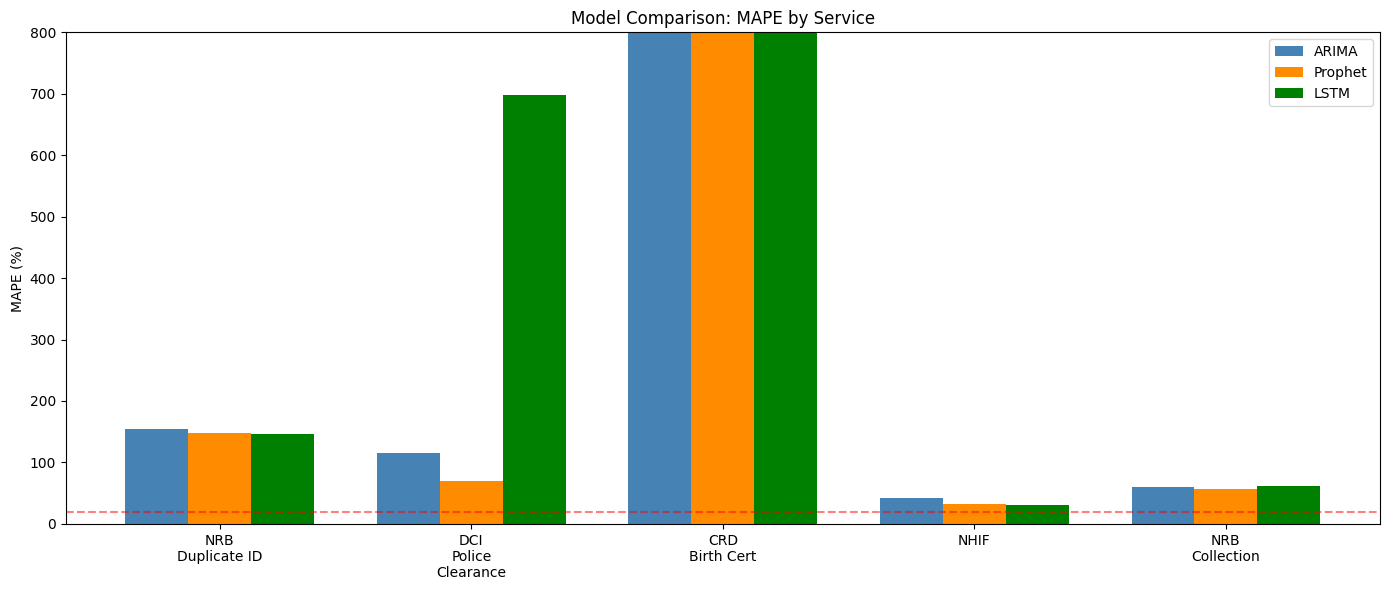

In [64]:
import matplotlib.pyplot as plt
import numpy as np

services_short = ['NRB\nDuplicate ID', 'DCI\nPolice\nClearance', 
                  'CRD\nBirth Cert', 'NHIF', 'NRB\nCollection']

arima_mape =   [154.04, 114.93, 3645.02, 42.60, 60.12]
prophet_mape = [148.00,  70.37, 10393.05, 32.50, 57.02]
lstm_mape =    [146.08, 698.23,  6222.78, 30.44, 62.07]

x = np.arange(len(services_short))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, arima_mape,   width, label='ARIMA',   color='steelblue')
ax.bar(x,         prophet_mape, width, label='Prophet', color='darkorange')
ax.bar(x + width, lstm_mape,    width, label='LSTM',    color='green')

ax.set_ylabel('MAPE (%)')
ax.set_title('Model Comparison: MAPE by Service')
ax.set_xticks(x)
ax.set_xticklabels(services_short)
ax.legend()
ax.set_ylim(0, 800)  # Cap at 800 to keep chart readable, CRD is an outlier
ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Good forecast threshold (20%)')
plt.tight_layout()
plt.show()

<p>CRD and DCI LSTM values exceed the chart boundary.</p>

In [65]:
import pandas as pd

comparison_data = {
    'Service': [
        'NRB - Duplicate ID',
        'DCI - Police Clearance', 
        'CRD - Birth Certificate',
        'NHIF - NHIF Services',
        'NRB - Collection of ID'
    ],
    'ARIMA_MAPE':   [154.04, 114.93, 3645.02, 42.60, 60.12],
    'Prophet_MAPE': [148.00,  70.37, 10393.05, 32.50, 57.02],
    'LSTM_MAPE':    [146.08, 698.23,  6222.78, 30.44, 62.07],
    'Best_Model':   ['LSTM', 'Prophet', 'ARIMA', 'LSTM', 'Prophet'],
    'Forecastable': ['Partial', 'Yes', 'No', 'Yes', 'Partial']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                Service  ARIMA_MAPE  Prophet_MAPE  LSTM_MAPE Best_Model Forecastable
     NRB - Duplicate ID      154.04        148.00     146.08       LSTM      Partial
 DCI - Police Clearance      114.93         70.37     698.23    Prophet          Yes
CRD - Birth Certificate     3645.02      10393.05    6222.78      ARIMA           No
   NHIF - NHIF Services       42.60         32.50      30.44       LSTM          Yes
 NRB - Collection of ID       60.12         57.02      62.07    Prophet      Partial


# Bussiness Impact

<p>A MAPE of 30% on NHIF Services means that if the model predicts 3,000 bookings in a quarter, the actual number will likely fall between 2,100 and 3,900. For operational planning purposes, this is actionable — a manager can prepare staffing and materials for a range rather than a single number. </p>

## Connecting Forecasts To Operational Decisions

<h3>Problem Being Solved</h3>
<p>Makandara Huduma Centre serves hundreds of citizens daily across 43 services. The current approach to staffing and material procurement is reactive — managers observe long queues and respond after the fact. This demand prediction system enables proactive management by forecasting quarterly service demand before the quarter begins</p>

<h3>For Each Forecastable Service</h3> <h4><b>NHIF Services (Best Model: LSTM, MAPE 30%)</b></h4> <ul> <li>Quarterly demand ranges between 1,337 and 3,384 bookings in the test period</li> <li>A forecast of ~3,000 bookings signals the need for additional NHIF-trained officers in that quarter</li> <li>Procurement of NHIF registration materials can be planned 4–6 weeks in advance</li> <li>Estimated impact: Reduced waiting time by pre-positioning resources before peak quarters</li> </ul> <h4><b>DCI Police Clearance (Best Model: Prophet, MAPE 70%)</b></h4> <ul> <li>Demand grew significantly from near zero (2020–2021) to over 9,000 quarterly bookings by mid-2022</li> <li>Even directional forecasts help management decide whether to increase DCI officer allocation</li> <li>A 70% MAPE means forecasts are directionally useful even if not precisely accurate</li> </ul> <h4><b>NRB Duplicate ID (All Models ~150% MAPE)</b></h4> <ul> <li>This is the highest volume service with over 130,000 total bookings</li> <li>Despite poor model accuracy, high volume justifies dedicated staffing regardless of forecasts</li> <li>The 2023 demand decline suggests the post-COVID ID backlog has cleared</li> <li>Management should expect lower but more stable demand going forward</li> </ul> <hr> <h3>The Cost of Getting It Wrong</h3> <p><b>There are two types of forecasting errors, each with real operational costs:</b></p> <h4>Under-prediction (Forecasting Too Low)</h4> <ul> <li>Insufficient staff deployed → long queues → citizen frustration</li> <li>Materials run out mid-quarter (e.g., ID booklets, birth certificate paper)</li> <li>Citizens make wasted trips and leave without being served</li> <li>Public trust in Huduma Centre services erodes</li> </ul> <h4>Over-prediction (Forecasting Too High)</h4> <ul> <li>Government overspends on underutilized staff</li> <li>Excess materials remain unused in storage</li> <li>Budget allocation becomes inefficient across service centers</li> </ul> <p> The goal of a demand prediction system is not perfect accuracy, but minimizing the cost of both types of errors over time. </p>

##  Visualization: Forecast vs Actual For Your Best Service

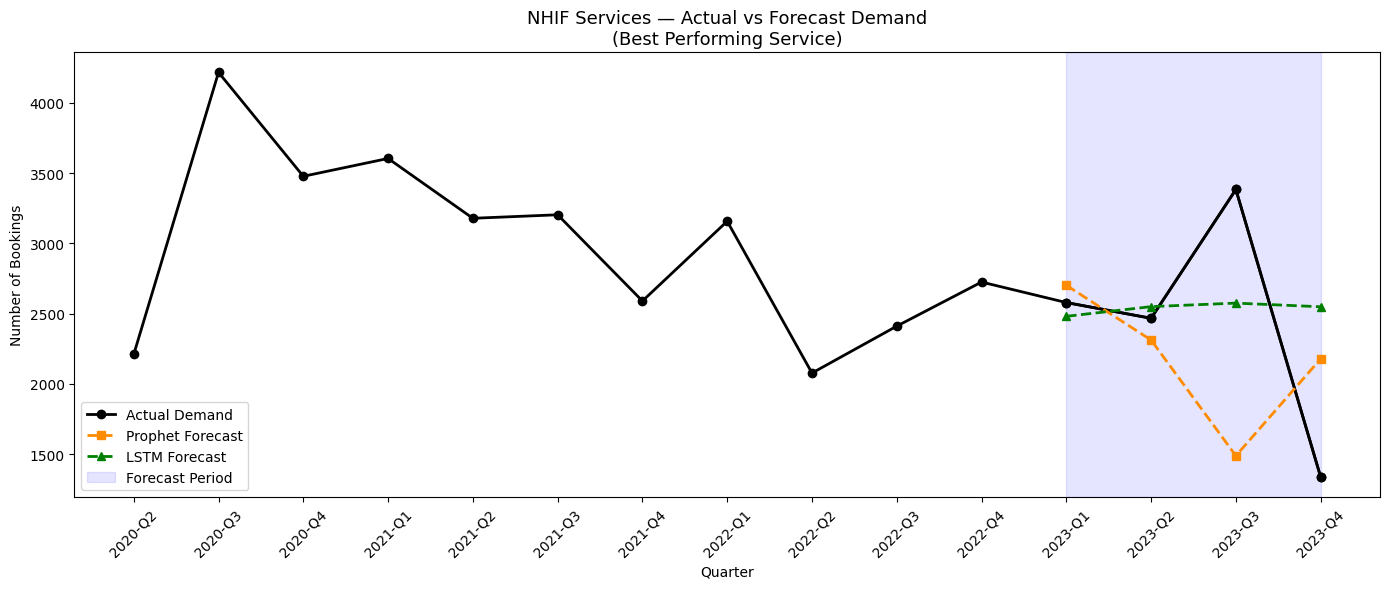

In [66]:
service_name = 'NHIF - NHIF Services'

# Get full series
nhif_data = top5_df[top5_df['servicename'] == service_name][['period','demand_count']].copy()
nhif_data = nhif_data.sort_values('period').reset_index(drop=True)

# Prophet forecast values for test period
nhif_prophet_forecast = [2702, 2312, 1488, 2178]
nhif_actual_test = [2579, 2467, 3384, 1337]
nhif_lstm_forecast = [2481, 2550, 2575, 2549]

test_periods = ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4']

fig, ax = plt.subplots(figsize=(14, 6))

# Plot full actual history
ax.plot(nhif_data['period'], nhif_data['demand_count'],
        marker='o', color='black', label='Actual Demand', linewidth=2)

# Highlight test period forecasts
ax.plot(test_periods, nhif_actual_test,
        marker='o', color='black', linewidth=2)
ax.plot(test_periods, nhif_prophet_forecast,
        marker='s', color='darkorange', linestyle='--', label='Prophet Forecast', linewidth=2)
ax.plot(test_periods, nhif_lstm_forecast,
        marker='^', color='green', linestyle='--', label='LSTM Forecast', linewidth=2)

# Shade the forecast region
ax.axvspan('2023-Q1', '2023-Q4', alpha=0.1, color='blue', label='Forecast Period')

ax.set_title('NHIF Services — Actual vs Forecast Demand\n(Best Performing Service)', fontsize=13)
ax.set_xlabel('Quarter')
ax.set_ylabel('Number of Bookings')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Notable observation
The black line (actual demand) shows NHIF has been relatively stable between 2,000-3,500 bookings per quarter throughout the entire period — with one notable spike in 2020-Q3 around 4,200 which was likely a post-lockdown surge.

# If This Were A Production System

### System Architecture

##### A production demand prediction system for Huduma Centres would consist of four components:

<ol> <li> <b>Data Pipeline</b> — The SBA booking system already captures all appointment data. An automated extract would pull new bookings at the end of each quarter, aggregate them by service, and append them to the historical dataset automatically. </li> <li> <b>Model Retraining</b> — The Prophet model would be retrained quarterly, immediately after each quarter closes. As more data accumulates, model accuracy is expected to improve significantly. By 2026–2027, the system would have 6–7 years of quarterly data, making SARIMA seasonal modeling viable. </li> <li> <b>Forecast Dashboard</b> — A simple dashboard for Huduma Centre managers displaying next quarter’s predicted demand per service, with traffic light indicators (green = normal demand, amber = elevated, red = surge expected) and recommended staffing levels based on forecast ranges. </li> <li> <b>Alert System</b> — If predicted demand for any service exceeds a defined capacity threshold, an automatic alert is sent to the center manager and procurement team at least 6 weeks in advance. </li> </ol>


### Retraining Schedule
<p>Retraining frequency: Quarterly — after Q1 closes in April, after Q2 closes in July, after Q3 closes in October, after Q4 closes in January. Each retraining adds one new data point, gradually improving model stability. A retraining log should be maintained recording: date retrained, new data added, previous vs new MAPE, and any anomalies detected</p>

### Model Monitoring and Drift Detection
<p>Over time, citizen behavior and government policies change. A model trained on 2020-2023 data may become less accurate by 2026 if service patterns shift. Drift detection should be implemented by comparing the model's rolling MAPE over the last 4 quarters against the baseline MAPE. If MAPE degrades by more than 20 percentage points, an alert triggers a full model review. This prevents the system from silently producing bad forecasts without anyone noticing</p>

### Known Limitations
#### This system has four key limitations that must be acknowledged
<ol> <li> <i><b>Limited training data</b> — 15 quarterly observations is below the recommended minimum for robust time series forecasting. Accuracy will improve significantly with each additional year of data.</i> </li> <li> <i><b>External shocks are unforecastable</b> — Events such as COVID-19 in 2020, the 2022 Kenyan general elections, and service disruptions like the CRD collapse in Q2 2023 cannot be predicted using historical data alone. The system should include a human override mechanism to allow managers to adjust forecasts when such events are anticipated.</i> </li> <li> <i><b>Single center scope</b> — This model is trained using data from Makadara Huduma Centre only. Demand patterns may vary significantly across other centers due to differences in demographics, location, and service availability. Each center would require its own model.</i> </li> <li> <i><b>Booking data vs actual attendance</b> — The SBA system captures bookings, not actual attendance. Walk-in citizens who do not book appointments are not recorded, meaning true demand may be higher than what the model forecasts.</i> </li> </ol>

### Recommended Next Steps
<h3>Future Improvements for a Production-Ready System</h3> <p><b>To evolve this system into a fully production-ready tool:</b></p> <ol> <li> <b>Collect monthly data instead of quarterly</b> — This increases training observations fourfold and enables more advanced models such as SARIMA with seasonality and more robust LSTM training. </li> <li> <b>Add external regressors to Prophet</b> — Incorporate variables such as national exam periods, election calendars, public holidays, and government policy announcements as additional predictive signals. </li> <li> <b>Expand to all 43 services</b> — Once the top 5 model is validated, extend forecasting to all services at Makadara, then scale across all 52 Huduma Centres nationally. </li> <li> <b>Integrate with procurement systems</b> — Connect forecast outputs directly to government procurement workflows so that material orders are automatically triggered when predicted demand exceeds a defined threshold. </li> <li> <b>Build a feedback loop</b> — After each quarter, compare forecast versus actual results, update the model, and track accuracy improvements over time to create a self-improving system. </li> </ol>


<h3>Final Summary</h3> <p> This project demonstrates that demand forecasting for e-government services is feasible even with limited historical data. <strong>Prophet</strong> emerged as the most reliable model overall, while <strong>LSTM</strong> showed promise on stable services like <strong>NHIF</strong> but failed on volatile ones such as <strong>DCI Police Clearance</strong>. This confirms that deep learning requires substantially more data than classical and modern statistical methods when working with small quarterly datasets. </p> <p> The most important finding is not which model performed best, but that even imperfect forecasts provide actionable operational intelligence. A forecast such as <em>"expect between 2,000 and 3,000 NHIF bookings next quarter"</em> is far more useful to a Huduma Centre manager than having no forecast at all. </p> <p> As more data accumulates through continued use of the SBA system, forecast accuracy is expected to improve, and the overall business value of this system will increase over time. </p>